# 03 — Uncertainty: evaluated nuclear data to dose σ

> **OpenBNCT is research software.** Nothing computed here is a clinical, equivalence, commissioning, or regulatory claim. See `docs/DISCLAIMER.md`.
>
> Run from the repository root after `pip install openbnct` (the notebooks read committed artifacts by repository-relative paths).

OpenBNCT propagates *evaluated* covariance — the uncertainty carried in ENDF evaluations — through the dose-response chain. This notebook inspects the committed artifacts: the ¹⁰B(n,α) covariance collapsed onto the 28-group mesh and the dose-uncertainty budget it produced.

## The covariance artifact

`openbnct.multigroup-covariance/0.1.0` binds a reaction's evaluated covariance to a multigroup group structure — here ENDF/B-VIII.1 ¹⁰B MT=107 (n,α), including NC-type derived-quantity references resolved by the reader.

In [1]:
from pathlib import Path
import json
import openbnct

# locate the repository root regardless of launch directory
REPO = Path.cwd()
while not (REPO / 'benchmarks').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / 'benchmarks').is_dir(), 'run inside an OpenBNCT checkout'

cov = openbnct.load_multigroup_covariance(
    REPO / 'examples/covariance/b10-endfb81-mt107-layered-head.covariance.json')
doc = json.loads(cov.to_json())
print(doc['id'])
print('blocks:', len(doc['blocks']))
blk = doc['blocks'][0]
print('material:', blk['material_id'])
print('parameter:', blk['parameter'], '| component:', blk['component'])
print('provenance:', doc['provenance_note'])

openbnct.covariance.openbnct.layered-head.brain.v1.mt107
blocks: 1
material: openbnct.layered-head.brain.v1
parameter: dose_response | component: boron
provenance: ENDF/B-VIII.1 n-005_B_010 MF33 MT=107 (n,alpha) — NC-type LTY=0 resolved through derived-quantity sections MT800+MT801 — collapsed to the 28-group boron dose-response mesh


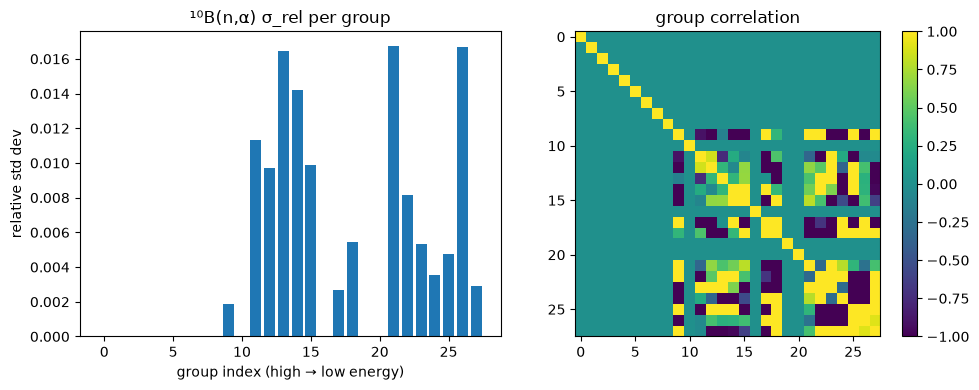

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# per-group relative standard deviation and the 28×28 correlation
# matrix (flattened row-major in the artifact)
rsd = np.array(blk['relative_std_dev'])
corr = np.array(blk['correlation']).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(28), rsd)
axes[0].set_xlabel('group index (high → low energy)')
axes[0].set_ylabel('relative std dev')
axes[0].set_title('¹⁰B(n,α) σ_rel per group')
im = axes[1].imshow(corr, cmap='viridis', vmin=-1, vmax=1)
axes[1].set_title('group correlation')
fig.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## The dose-uncertainty budget

`uq propagate` folds the covariance through the component's dose-response vector — analytic sensitivities, no perturbed solves. The committed budget records every contribution and the total.

In [3]:
budget = openbnct.load_dose_uncertainty_budget(
    REPO / 'examples/covariance/layered-head-endf-b10na-budget.json')
bd = json.loads(budget.to_json())
print('component:', bd['component'])
print('response integral:', f"{bd['response_integral']:.3e}")
print('total σ_rel:', f"{bd['total_relative_std_dev']:.4%}")
print()
for e in bd['entries']:
    print(f"  {e['source']:<40} share {e['relative_contribution']:.2%} "
          f"(variance contribution {e['variance_contribution']:.3e})")
print()
print('method:', bd['method_note'])

component: boron
response integral: 6.231e-14
total σ_rel: 0.3402%

  response_data                            share 100.00% (variance contribution 4.495e-32)

method: central-difference sensitivities (δ_rel=0.001) on the deterministic solve times the declared covariance; diagonal entries independent, blocks dense group-correlated; scatter entries uncorrelated (declared-data limitation); 0 perturbed solves


The entire evaluated-¹⁰B(n,α) uncertainty contributes 0.34% σ_rel on the boron dose integral — the evaluation is tight thermally where the response concentrates. The same chain accepts systematic terms (boron concentration, positioning, component scale) via `openbnct uq propagate`.

**Where to go deeper:** `docs/USAGE.md` covers `uq`, `cov-endf`, and the sensitivity-screening surfaces; `examples/covariance/README.md` reproduces this artifact end to end.